# SqueezeLLM / VPTQ / CLAQ：敏感性加权低比特量化

> **对应博客**：《PTQ（09）：SqueezeLLM、VPTQ 与 CLAQ——敏感度度量与非均匀量化的低比特之路》
> （系列导航：RTN/LLM.int8 → GPTQ → AWQ/OmniQuant → SpQR/OWQ/HQQ → QuIP#/AQLM → … → **本篇** → Outlier Suppression → …）

**一段话原理**：层输出重构目标 $\|XW^\top - X\hat{W}^\top\|^2$ 在 Hessian 对角近似下等于
$\sum_{ij} h_i (w_{ij} - \hat{w}_{ij})^2$，其中 $h_i = \sum_t x_{ti}^2$ 是第 $i$ 个输入通道的激活能量——这就是层内口径的**敏感度**
（SqueezeLLM 用对角 Fisher 信息的梯度平方近似来估计它）。把它当成逐坐标权重，量化就变成**敏感度加权的 k-means**：
Lloyd 迭代的分配步（就近电平）与更新步（$c_k = \sum_j s_j w_j \,/\, \sum_j s_j$）都有闭式解，
电平会自动向敏感区域偏移——这是 SqueezeLLM / CLAQ 的非均匀码本思想。两个关键工程细节：
**(a)** 加权 k-means 必须从普通 k-means 解**热启动**，冷启动会掉进更差的局部最优；
**(b)** 聚类前要**逐块尺度归一**，防止大尺度块劫持共享码本。
当位宽压到 2-bit，标量码本只剩 4 个电平、容量见底——把 $d$ 个权重拼成向量共享一个索引（位宽摊薄为 $\log_2 K / d$ bit）
就是 VPTQ / AQLM 的向量量化路线；再按显著度 $h \cdot w^2$ 把极少数坐标保成 FP16，即 SqueezeLLM 的 dense-and-sparse 分解。

**本 demo 五步**：数据构造 → 工具函数（目标函数 + 三种码本学习器）→ 4-bit 同台对比与初始化消融 → 2-bit 容量扫描 → dense-and-sparse。
纯 numpy + matplotlib，固定 SEED=0，全程秒级可复现。

## 第 1 步 · 数据构造

**这一步在做什么**：合成一个玩具线性层 $W \in \mathbb{R}^{128 \times 192}$ 与校准激活 $X \in \mathbb{R}^{4096 \times 128}$——
少数输入通道激活能量放大 100 倍（模拟真实 LLM 的 outlier channel），权重里撒 2% 的 8 倍大值（模拟重尾离群权重），
并从 $h_i = \sum_t x_{ti}^2$ 得到每个输入行坐标的敏感度。

In [1]:
import numpy as np
import matplotlib.pyplot as plt

SEED = 0
T, K, N = 4096, 128, 192          # token 数 / 输入通道 / 输出通道, W 为 K x N <= 512 x 512

def make_problem():
    '''合成带敏感通道与稀疏大权重的玩具线性层.'''
    rng = np.random.default_rng(SEED)
    X = rng.standard_normal((T, K))
    hot = rng.choice(K, size=8, replace=False)
    X[:, hot] *= 10.0                   # 8 个敏感通道: 激活能量 x100
    W = rng.standard_normal((K, N))
    mask = rng.random((K, N)) < 0.02
    W[mask] *= 8.0                      # 2% 稀疏离群大权重
    return X, W

X, W = make_problem()
h = np.sum(X ** 2, axis=0)              # 敏感度: 每个输入通道的激活能量
Hmat = np.repeat(h[:, None], N, axis=1)
print('X:', X.shape, '  W:', W.shape)
q50, q90, qmax = np.quantile(h, [0.5, 0.9, 1.0])
print('敏感度 h 分位数 [50%%, 90%%, max]: %.3g / %.3g / %.3g  (跨约两个数量级)' % (q50, q90, qmax))
corr = np.corrcoef(Hmat.ravel(), np.abs(W).ravel())[0, 1]
print('corr(h, |w|) = %.3f   <-- 敏感度与权重幅值几乎无关, 加权保护的是"敏感行上的坐标"' % corr)
print('|W| 最大值: %.2f (普通高斯权重约为 4)' % np.abs(W).max())

X: (4096, 128)   W: (128, 192)
敏感度 h 分位数 [50%, 90%, max]: 4.1e+03 / 4.27e+03 / 4.28e+05  (跨约两个数量级)
corr(h, |w|) = 0.003   <-- 敏感度与权重幅值几乎无关, 加权保护的是"敏感行上的坐标"
|W| 最大值: 23.34 (普通高斯权重约为 4)


## 第 2 步 · 目标函数与工具函数

**这一步在做什么**：实现评估指标（层输出相对 MSE）与三种码本学习器——RTN 均匀网格、普通/加权 1-D k-means（Lloyd 迭代，
更新步闭式 $c_k = \sum s_j w_j / \sum s_j$，支持热启动），以及完整的量化管线：**逐块尺度归一 → 聚类 → 反归一化**。
归一把目标变成 $\sum_{ij} (h_i s_b^2)(u_{ij}-v_{ij})^2$，因此归一空间里的敏感度权重是 $h_i s_b^2$。

In [2]:
def out_rel_mse(X, W, Wq):
    '''层输出相对 MSE: ||X(W-Wq)^T||^2 / ||XW^T||^2.
    对角近似下正比于 sum_ij h_i (w_ij - q_ij)^2, 即敏感度加权重构误差.'''
    E = X @ (W - Wq)
    return float(np.sum(E ** 2) / np.sum((X @ W) ** 2))

def rtn_codebook(w, n_lev):
    '''RTN: 覆盖 [min, max] 的均匀网格, 取相邻边界中点作电平.'''
    edges = np.linspace(w.min(), w.max(), n_lev + 1)
    return (edges[:-1] + edges[1:]) / 2.0

def lloyd_1d(w, hw, n_lev, iters=150, warm=None):
    '''1D (加权) k-means. 分配步用中点决策边界的 searchsorted;
    更新步闭式 c_k = sum(hw*w)/sum(hw). warm 传入现成码本即为热启动,
    否则用分位数初始化 (冷启动).'''
    cent = warm if warm is not None else np.quantile(w, (np.arange(n_lev) + 0.5) / n_lev)
    for _ in range(iters):
        idx = np.searchsorted((cent[:-1] + cent[1:]) / 2, w)
        new = cent.copy()
        for k in range(n_lev):
            m = idx == k
            if m.any():
                new[k] = np.sum(hw[m] * w[m]) / np.sum(hw[m])
        if np.allclose(new, cent):
            break
        cent = new
    return cent

def apply_vals(w, cent):
    '''按最近电平(决策边界为中点)给一组标量赋码.'''
    mid = (cent[:-1] + cent[1:]) / 2.0
    return cent[np.searchsorted(mid, w)]

def normalize_blocks(W, n_blocks=4):
    '''逐块尺度归一: 每个列块除以自己的 max-abs, 防止大尺度块劫持共享码本.'''
    Bw = W.shape[1] // n_blocks
    scales = np.array([np.abs(W[:, b * Bw:(b + 1) * Bw]).max() for b in range(n_blocks)])
    Wn = np.empty_like(W)
    for b in range(n_blocks):
        sl = slice(b * Bw, (b + 1) * Bw)
        Wn[:, sl] = W[:, sl] / scales[b]
    return Wn, scales

def dequant_norm(Wn, cent, scales, n_blocks=4):
    '''归一空间查码本, 再按块乘回尺度.'''
    Bw = Wn.shape[1] // n_blocks
    Wq = np.empty_like(Wn)
    for b in range(n_blocks):
        sl = slice(b * Bw, (b + 1) * Bw)
        Wq[:, sl] = apply_vals(Wn[:, sl], cent) * scales[b]
    return Wq

def quantize_blockwise(W, h, n_lev, mode='plain', n_blocks=4):
    '''完整管线: 逐块尺度归一 -> 学一份共享码本 -> 反归一化.
    mode: 'plain'  普通 k-means (无敏感度, CLAQ 列级码本思想的简化版)
          'cold_q' 加权 k-means, 分位数冷启动   <-- 已知坑: 会掉坏局部最优
          'cold_r' 加权 k-means, 随机冷启动     <-- 已知坑
          'warm'   加权 k-means, 从普通 k-means 解热启动 <-- 正确姿势'''
    Wn, scales = normalize_blocks(W, n_blocks)
    wn = Wn.ravel()
    Bw = W.shape[1] // n_blocks
    if mode == 'plain':
        hw = np.ones_like(wn)
    else:
        hw = np.repeat(h[:, None] * (scales ** 2)[None, :], Bw, axis=1).ravel()  # 归一空间权重 h*s^2
    c_plain = lloyd_1d(wn, np.ones_like(wn), n_lev)
    if mode == 'warm':
        cent = lloyd_1d(wn, hw, n_lev, warm=c_plain.copy())
    elif mode == 'cold_r':
        rng = np.random.default_rng(SEED + 7)
        cent = lloyd_1d(wn, hw, n_lev, warm=np.sort(rng.choice(wn, n_lev, replace=False)))
    elif mode == 'cold_q':
        cent = lloyd_1d(wn, hw, n_lev)
    else:
        cent = c_plain
    return dequant_norm(Wn, cent, scales, n_blocks)

print('工具函数就绪: out_rel_mse / rtn_codebook / lloyd_1d / normalize_blocks / quantize_blockwise')

工具函数就绪: out_rel_mse / rtn_codebook / lloyd_1d / normalize_blocks / quantize_blockwise


## 第 3 步 · 4-bit 同台对比与初始化消融

**这一步在做什么**：同样 16 个电平（4-bit），比较五种方案的层输出误差——朴素 RTN、逐块归一 + 普通 k-means、
加权 k-means 的两种冷启动（分位数 / 随机）、以及从普通 k-means 解**热启动**的加权 k-means，
验证已知坑：加权 k-means 冷启动反而更差，热启动才能兑现敏感性加权的收益。

4-bit (16 电平) 层输出相对 MSE:
  RTN 均匀网格(全张量): 3.0074e-01
  逐块归一+普通k-means: 2.1452e-02
  加权k-means 冷启动(分位数): 3.7656e-02
  加权k-means 冷启动(随机): 3.7123e-02
  加权k-means 热启动<-普通k-means: 1.6932e-02

>> 冷启动的加权 k-means (3.7656e-02 / 3.7123e-02) 比不加权还差 76%:
   敏感度加权改写了目标地形, Lloyd 从冷启动出发掉进坏局部最优;
>> 热启动后 1.6932e-02, 较普通 k-means 再降 21.1% -- 敏感性加权的真实收益.


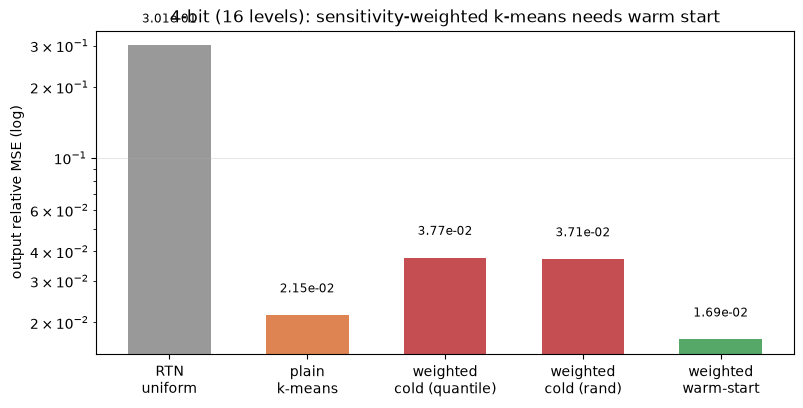

In [3]:
N_LEV = 16                                    # 4-bit 码本

# 基线: 全张量 RTN 均匀网格 (不做任何归一/聚类)
c_rtn = rtn_codebook(W.ravel(), N_LEV)
W_rtn = apply_vals(W.ravel(), c_rtn).reshape(K, N)

results = [('RTN 均匀网格(全张量)', out_rel_mse(X, W, W_rtn))]
for tag, mode in [('逐块归一+普通k-means', 'plain'),
                  ('加权k-means 冷启动(分位数)', 'cold_q'),
                  ('加权k-means 冷启动(随机)', 'cold_r'),
                  ('加权k-means 热启动<-普通k-means', 'warm')]:
    Wq = quantize_blockwise(W, h, N_LEV, mode=mode)
    results.append((tag, out_rel_mse(X, W, Wq)))

m_rtn, m_km, m_coldq, m_coldr, m_warm = [v for _, v in results]
print('4-bit (%d 电平) 层输出相对 MSE:' % N_LEV)
for tag, v in results:
    print('  %s: %.4e' % (tag, v))
print()
print('>> 冷启动的加权 k-means (%.4e / %.4e) 比不加权还差 %.0f%%:' % (
    m_coldq, m_coldr, 100 * (m_coldq / m_km - 1)))
print('   敏感度加权改写了目标地形, Lloyd 从冷启动出发掉进坏局部最优;')
print('>> 热启动后 %.4e, 较普通 k-means 再降 %.1f%% -- 敏感性加权的真实收益.' % (
    m_warm, 100 * (1 - m_warm / m_km)))

# 画图: 五方案柱状图 (y 轴对数)
fig, ax = plt.subplots(figsize=(9, 4.2))
labels = ['RTN\nuniform', 'plain\nk-means', 'weighted\ncold (quantile)',
          'weighted\ncold (rand)', 'weighted\nwarm-start']
vals = [v for _, v in results]
colors = ['#999999', '#DD8452', '#C44E52', '#C44E52', '#55A868']
bars = ax.bar(labels, vals, color=colors, width=0.6)
ax.set_yscale('log')
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v * 1.25, '%.2e' % v,
            ha='center', fontsize=8.5)
ax.set_ylabel('output relative MSE (log)')
ax.set_title('4-bit (16 levels): sensitivity-weighted k-means needs warm start')
ax.grid(axis='y', alpha=0.3)
plt.show()

## 第 4 步 · 2-bit 极限下的码本容量扫描

**这一步在做什么**：把码本大小从 64 电平一路砍到 4 电平（6-bit → 2-bit），画误差-位宽曲线，
并在 4-bit 处画出归一化权重直方图上三种码本的实际位置——看非均匀码本把电平摆到了哪里，
以及 2-bit 时标量码本的容量墙在哪里（这正是 VPTQ/AQLM 转向向量量化的动机）。

码本容量扫描 (逐块归一空间, 层输出相对 MSE):
levels   bits |        RTN    k-means w-cold(quantile)       w-warm
     4     2-bit |  8.395e+00  2.840e-01    3.229e-01    2.697e-01
     8     3-bit |  1.538e+00  1.139e-01    9.033e-02    8.407e-02
    16     4-bit |  2.533e-01  2.145e-02    3.766e-02    1.693e-02
    64     6-bit |  1.551e-02  6.130e-03    2.904e-02    2.731e-03

>> 2-bit 时 RTN 崩溃 (8.40, 误差远超信号本身), 三种学习码本挤在一起 (0.284 vs 0.270):
   容量不足时加权只有 5% 腾挪空间; 6-bit 时扩大到 55%.
>> 要突破这堵墙, 就把 d 个权重拼成向量共享一个索引: 位宽 = log2(K)/d -- 这就是 VPTQ/AQLM 的起点.


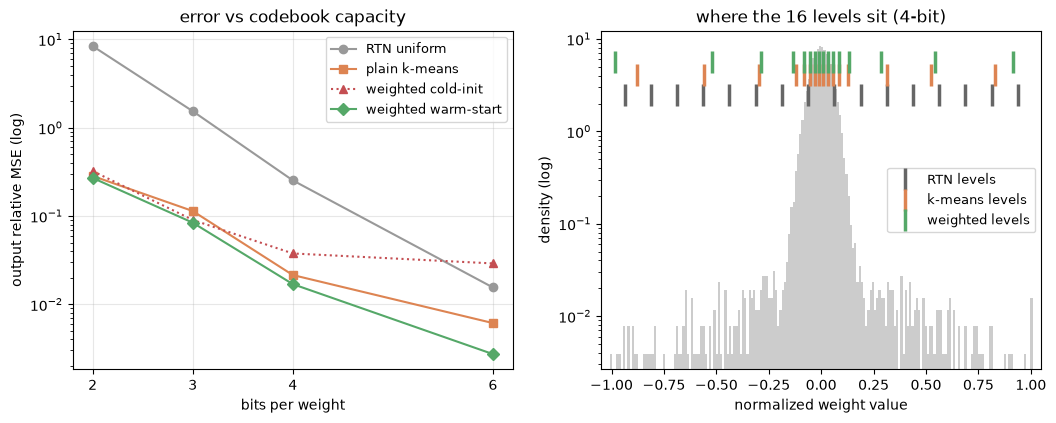

In [4]:
sizes = [4, 8, 16, 64]                       # 2 / 3 / 4 / 6 bit
bits = [int(np.log2(s)) for s in sizes]

Wn, scales = normalize_blocks(W)
wn = Wn.ravel()
Hn = np.repeat(h[:, None] * (scales ** 2)[None, :], N // 4, axis=1).ravel()

curve = {'rtn': [], 'km': [], 'cold': [], 'warm': []}
store = {}                                   # 留下各尺寸的码本用于画图
for nl in sizes:
    c_rtn = rtn_codebook(wn, nl)
    c_km = lloyd_1d(wn, np.ones_like(wn), nl)
    c_cold = lloyd_1d(wn, Hn, nl)                       # 加权, 冷启动
    c_warm = lloyd_1d(wn, Hn, nl, warm=c_km.copy())     # 加权, 热启动
    for key, c in [('rtn', c_rtn), ('km', c_km), ('cold', c_cold), ('warm', c_warm)]:
        curve[key].append(out_rel_mse(X, W, dequant_norm(Wn, c, scales)))
    store[nl] = {'rtn': c_rtn, 'km': c_km, 'warm': c_warm}

print('码本容量扫描 (逐块归一空间, 层输出相对 MSE):')
print('%6s %6s | %10s %10s %12s %12s' % ('levels', 'bits', 'RTN', 'k-means',
                                         'w-cold(quantile)', 'w-warm'))
for i, nl in enumerate(sizes):
    print('%6d %5d-bit | %10.3e %10.3e %12.3e %12.3e' % (
        nl, bits[i], curve['rtn'][i], curve['km'][i],
        curve['cold'][i], curve['warm'][i]))
print()
print('>> 2-bit 时 RTN 崩溃 (%.2f, 误差远超信号本身), 三种学习码本挤在一起 (%.3f vs %.3f):'
      % (curve['rtn'][0], curve['km'][0], curve['warm'][0]))
print('   容量不足时加权只有 %.0f%% 腾挪空间; 6-bit 时扩大到 %.0f%%.' % (
      100 * (1 - curve['warm'][0] / curve['km'][0]),
      100 * (1 - curve['warm'][3] / curve['km'][3])))
print('>> 要突破这堵墙, 就把 d 个权重拼成向量共享一个索引: 位宽 = log2(K)/d -- 这就是 VPTQ/AQLM 的起点.')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.4))
styles = {'rtn': ('o-', '#999999', 'RTN uniform'),
          'km': ('s-', '#DD8452', 'plain k-means'),
          'cold': ('^:', '#C44E52', 'weighted cold-init'),
          'warm': ('D-', '#55A868', 'weighted warm-start')}
for key, (st, col, lab) in styles.items():
    ax1.semilogy(bits, curve[key], st, color=col, label=lab)
ax1.set_xticks(bits)
ax1.set_xlabel('bits per weight')
ax1.set_ylabel('output relative MSE (log)')
ax1.set_title('error vs codebook capacity')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

nl = 16
ax2.hist(wn, bins=200, range=(-1.05, 1.05), color='#cccccc', density=True)
ax2.set_yscale('log')
for row, (key, col, lab) in enumerate([('rtn', '#666666', 'RTN levels'),
                                       ('km', '#DD8452', 'k-means levels'),
                                       ('warm', '#55A868', 'weighted levels')]):
    c = store[nl][key]
    ax2.plot(c, np.full(nl, 2.5 + row * 1.6), linestyle='', marker='|',
             ms=16, mew=2.5, color=col, label=lab)
ax2.set_xlim(-1.05, 1.05)
ax2.set_xlabel('normalized weight value')
ax2.set_ylabel('density (log)')
ax2.set_title('where the 16 levels sit (4-bit)')
ax2.legend(fontsize=9)
plt.show()

## 第 5 步 · dense-and-sparse 分解（SqueezeLLM 的第二件武器）

**这一步在做什么**：对少数"连最近的电平都救不回来"的坐标，直接保留 FP16 原值（稀疏残差），
其余坐标走 4-bit 码本（稠密低比特）——显著度用 OBS 式的 $h_i w_{ij}^2$ 排序，
分别测试保留 0.2% 与 1% 坐标时的误差变化。

dense-and-sparse (基线: 4-bit 普通 k-means, 相对 MSE = 2.1452e-02):
  保留 0.2% 坐标为 FP16 (49 个): 1.0831e-02  (较全量化再降 49.5%)
  保留 1.0% 坐标为 FP16 (245 个): 8.5990e-03  (较全量化再降 59.9%)


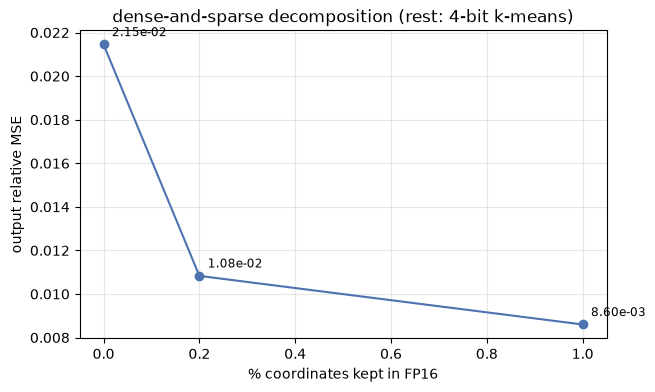

In [5]:
saliency = (W ** 2) * Hmat                     # OBS 式显著度: h * w^2
order = np.argsort(saliency.ravel())[::-1]

W_base = quantize_blockwise(W, h, N_LEV, mode='plain')     # 其余坐标: 逐块归一普通 k-means
m_base = out_rel_mse(X, W, W_base)
print('dense-and-sparse (基线: 4-bit 普通 k-means, 相对 MSE = %.4e):' % m_base)

fracs = [0.0, 0.002, 0.01]
ms = [m_base]
for frac in fracs[1:]:
    keep = np.zeros(W.size, dtype=bool)
    keep[order[:int(frac * W.size)]] = True
    W_ds = W_base.copy()
    W_ds.reshape(-1)[keep] = W.ravel()[keep]               # 敏感坐标保 FP16
    m = out_rel_mse(X, W, W_ds)
    ms.append(m)
    print('  保留 %.1f%% 坐标为 FP16 (%d 个): %.4e  (较全量化再降 %.1f%%)'
          % (frac * 100, int(frac * W.size), m, 100 * (1 - m / m_base)))

fig, ax = plt.subplots(figsize=(6.8, 4))
xs = [f * 100 for f in fracs]
ax.plot(xs, ms, 'o-', color='#4C72B0')
for xv, mv in zip(xs, ms):
    ax.annotate('%.2e' % mv, (xv, mv), textcoords='offset points',
                xytext=(6, 6), fontsize=8.5)
ax.set_xlabel('% coordinates kept in FP16')
ax.set_ylabel('output relative MSE')
ax.set_title('dense-and-sparse decomposition (rest: 4-bit k-means)')
ax.grid(alpha=0.3)
plt.show()

## 结果解读（SEED=0 实测，可复现）

1. **非均匀码本是低比特的主战场**。同为 16 电平（4-bit），全张量 RTN 均匀网格误差 3.0074e-01；逐块尺度归一＋普通 k-means 直接降到 2.1452e-02（约降 93%）——电平按分布形状摆放比等距摆放重要得多。右图可见学到的码本在 0 附近密、尾部疏，恰好贴合权重的重尾形状；这就是 CLAQ「列级 k-means 码本」想吃到的主要红利。
2. **敏感性加权必须热启动（本篇最重要的坑）**。分位数／随机冷启动的加权 k-means 收敛到 3.7656e-02／3.7123e-02，比不加权的普通 k-means 还差约 76%——敏感度权重改写了目标地形，Lloyd 从冷启动出发掉进坏局部最优；先求无权解、再以此为初值做加权 Lloyd，才拿到 1.6932e-02，较普通 k-means 再降 21.1%。注意本构造里 corr(h, |w|) ≈ 0.003：这份收益与「保护大权重」无关，纯粹来自把码本分辨率让给敏感行上的坐标。
3. **2-bit 是标量码本的容量墙**。4 电平时 RTN 崩到 8.40（误差远超信号本身），普通／加权 k-means 也挤在 2.697e-01～2.840e-01，加权只剩 5% 的腾挪空间；位宽升到 6-bit 后加权增益才扩大到 55%。要突破这堵墙必须换几何——VPTQ／AQLM 把 $d$ 个权重拼成向量共享一个索引，位宽摊薄为 $\log_2 K / d$ bit/权重（如 $K{=}65536, d{=}8$ 时即 2 bit）。
4. **dense-and-sparse 兜底离群值**。按显著度 $h \cdot w^2$ 只保留 0.2%（49 个）坐标为 FP16，误差从 2.1452e-02 再降 49.5% 到 1.0831e-02；保留 1%（245 个）时达 8.5990e-03（再降 59.9%）。另注意：若把它叠在「已加权」的码本上，边际收益会缩水——FP16 保住的正是敏感坐标，与加权的功能部分重叠。

## 方法局限

- 敏感度 $h_i=\sum_t x_{ti}^2$ 只是 Hessian 对角近似（真实 SqueezeLLM 用对角 Fisher／梯度平方估计，且需足够多校准样本平均以压方差），完全忽略坐标间耦合；
- 共享 1-D 码本无法表达列间相关结构，2-bit 下天花板明显（相对 MSE 约 0.27）——这正是向量量化（VPTQ／AQLM）与旋转路线（QuaRot／SpinQuant）要解决的问题；
- LUT gather、逐块尺度、稀疏残差分支都会打断 Tensor Core 的整齐流水线：这一族方法精度领先但 kernel 难产，均未成为部署默认项；
- 码本与逐块尺度是额外元数据，若只按「索引位宽」报告压缩率会轻微美化实际显存收益。